In [8]:
from matplotlib import pyplot as plt
import numpy as np
import os
import random
import time

# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, LSTM

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progrepcss bar for loading data
from tqdm.notebook import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# resample signal to n samples
from scipy.signal import resample

# XML parser
import xml.etree.ElementTree as ET

# encoding and normalizing data
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [9]:
NUM_POINTS = 64  # same as dolalr recognizer

gestures = ["arrow", "caret", "check", "circle", "delete_mark", "left_curly_brace",
    "left_sq_bracket", "pigtail", "rectangle",
    "right_curly_brace", "right_sq_bracket", "star", "triangle", "v", "x"]
# exlclude question mark because its not on dollar recognizer website, also exclude zigziag from website bc not in logs

## Read Data

In [10]:
def get_training_data(num_pts):
    data = []

    for root, subdirs, files in os.walk('xml_logs'):
        if 'ipynb_checkpoint' in root:
            continue
        
        if len(files) > 0:
            for f in tqdm(files):
                if '.xml' in f:
                    fname = f.split('.')[0]
                    label = fname[:-2]
                    
                    if label not in gestures:
                        continue
                    
                    xml_root = ET.parse(f'{root}/{f}').getroot()
                    
                    points = []
                    for element in xml_root.findall('Point'):
                        x = element.get('X')
                        y = element.get('Y')
                        points.append([x, y])
                        
                    points = np.array(points, dtype=float)
                    
                    scaler = StandardScaler()
                    points = scaler.fit_transform(points)
                    
                    resampled = resample(points, num_pts)
                    
                    data.append((label, resampled))
    return data

In [11]:
def get_own_data(num_pts):
    own_data = []

    for root, subdirs, files in os.walk('datasets'):
        if 'ipynb_checkpoint' in root:
            continue
        
        if len(files) > 0:
            for f in tqdm(files):
                if '.xml' in f:
                    fname = f.split('.')[0]
                    label = fname[:-2]
                    
                    xml_root = ET.parse(f'{root}/{f}').getroot()
                    
                    points = []
                    for element in xml_root.findall('Point'):
                        x = element.get('X')
                        y = element.get('Y')
                        points.append([x, y])
                        
                    points = np.array(points, dtype=float)
                    
                    scaler = StandardScaler()
                    points = scaler.fit_transform(points)
                    
                    resampled = resample(points, num_pts)
                    
                    own_data.append((label, resampled))
    return own_data

## Prepare Data

In [12]:
data = get_training_data(NUM_POINTS)
own_data = get_own_data(NUM_POINTS)

# Prepare the data
labels = [sample[0] for sample in data]
own_labels = [sample[0] for sample in own_data]

print("labels: ", set(labels))
print("own_labels: ", set(own_labels))

# encode (make string-labels numerical)
encoder = LabelEncoder()
labels_encoded = encoder.fit_transform(labels)
own_labels_encoded = encoder.transform(own_labels)
# print("encoded: ", set(labels_encoded))

num_classes = len(encoder.classes_)
# get labels of data
y_train = to_categorical(labels_encoded, num_classes=num_classes)
y_test = to_categorical(own_labels_encoded, num_classes=num_classes)
# print("num labels (encoded): ", len(y[0]))

# get point sequences of data
sequences = [sample[1] for sample in data]
X_train = np.array(sequences)

own_sequences = [sample[1] for sample in own_data]
X_test = np.array(own_sequences)


print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
# print(y_train)

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

...

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

labels:  {'x', 'triangle', 'delete_mark', 'arrow', 'v', 'circle', 'caret', 'right_sq_bracket', 'rectangle', 'left_sq_bracket', 'pigtail', 'right_curly_brace', 'check', 'left_curly_brace', 'star'}
own_labels:  {'x', 'triangle', 'delete_mark', 'arrow', 'v', 'circle', 'caret', 'right_sq_bracket', 'rectangle', 'left_sq_bracket', 'pigtail', 'right_curly_brace', 'check', 'left_curly_brace', 'star'}
(4950, 64, 2) (150, 64, 2) (4950, 15) (150, 15)


## Define and Train Models
### Parameter Reduction

Then, try to systematically reduce the LSTM’s parameter count. Create at least three different versions
eport method and results in a Jupyter
Notebook called unistroke_gestures.ipynb.


In [31]:
# Define the model
LSTM_UNITS = 16

model = Sequential()

# add LSTM layer
# input shape is (length of an individual sample, dimensions of the sample)
# in our case: two dimensions, as we have X and Y coordinates

# old syntax
#model.add(LSTM(64, input_shape=(NUM_POINTS, 2)))

# new syntax
model.add(Input((NUM_POINTS, 2)))
model.add(LSTM(LSTM_UNITS))

# add dense layer to do machine learning magic
model.add(Dense(32, activation='relu'))

# here, you can add more layers and maybe a dropout for better performance

# softmax layer for classification
model.add(Dense(len(set(labels)), activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
stop_early = EarlyStopping(monitor='val_loss', patience=3)

In [32]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=10, 
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[reduce_lr, stop_early]
)

Epoch 1/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.3485 - loss: 2.0959 - val_accuracy: 0.4933 - val_loss: 1.3943 - learning_rate: 0.0010
Epoch 2/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6990 - loss: 0.9682 - val_accuracy: 0.6467 - val_loss: 0.9014 - learning_rate: 0.0010
Epoch 3/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8768 - loss: 0.5006 - val_accuracy: 0.6333 - val_loss: 0.8803 - learning_rate: 0.0010
Epoch 4/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9368 - loss: 0.2574 - val_accuracy: 0.7467 - val_loss: 0.6684 - learning_rate: 0.0010
Epoch 5/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9697 - loss: 0.1399 - val_accuracy: 0.7467 - val_loss: 0.7370 - learning_rate: 0.0010
Epoch 6/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9788 - loss: 0.0929 - val_accuracy: 0.7467 - val_loss: 0.7410 - learning_rate: 0.0010
Epoch 7/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9879 - loss: 0.

In [33]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 16)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,767 (26.44 KB)

 Trainable params: 2,255 (8.81 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,512 (17.63 KB)

### Parameters
- Total params with 64 LSTM cells: 59,183
    - LSTM layer:  17,152
- Total params with 32 LSTM cells: 18,095
    - LSTM layer:  4,480
- Total params with 16 LSTM cells:   6,767
    - LSTM layer:  1,216 


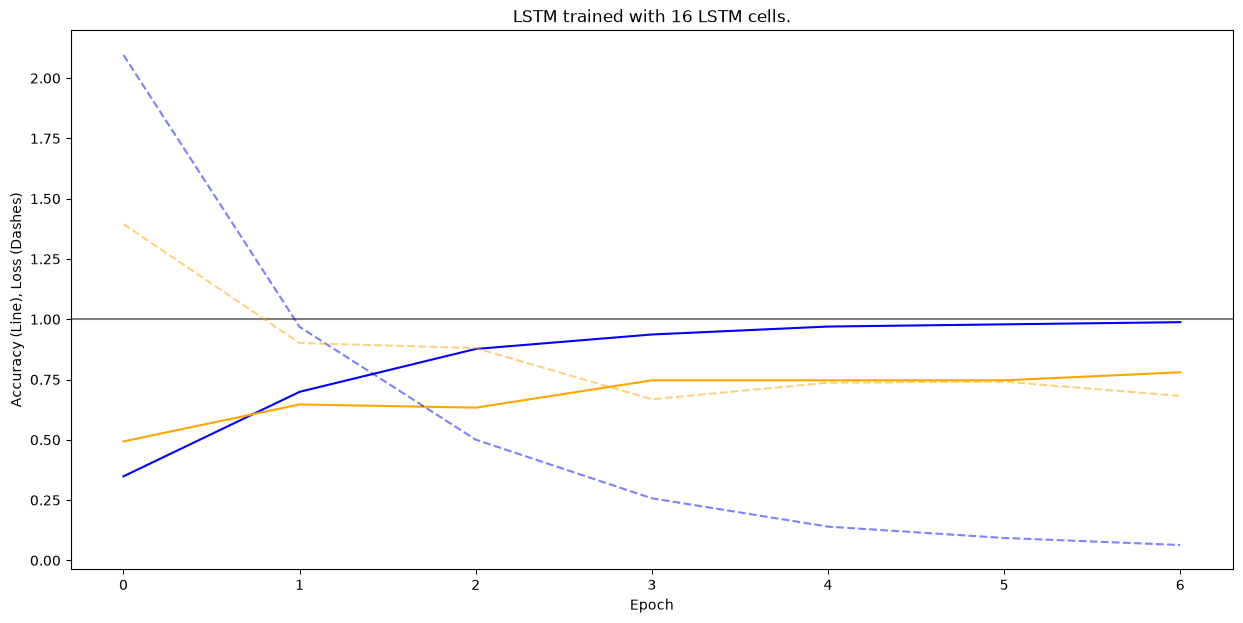

In [34]:
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

fig = plt.figure(figsize=(15, 7))
ax = plt.gca()

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (Line), Loss (Dashes)')

ax.axhline(1, color='gray')

plt.title(f"LSTM trained with {LSTM_UNITS} LSTM cells.")
plt.plot(accuracy, color='blue')
plt.plot(val_accuracy, color='orange')
plt.plot(loss, '--', color='blue', alpha=0.5)
plt.plot(val_loss, '--', color='orange', alpha=0.5)


plt.savefig(f"./plots/accuracy_and_loss{LSTM_UNITS}.png", dpi=300, bbox_inches="tight")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


<Figure size 1000x1000 with 0 Axes>

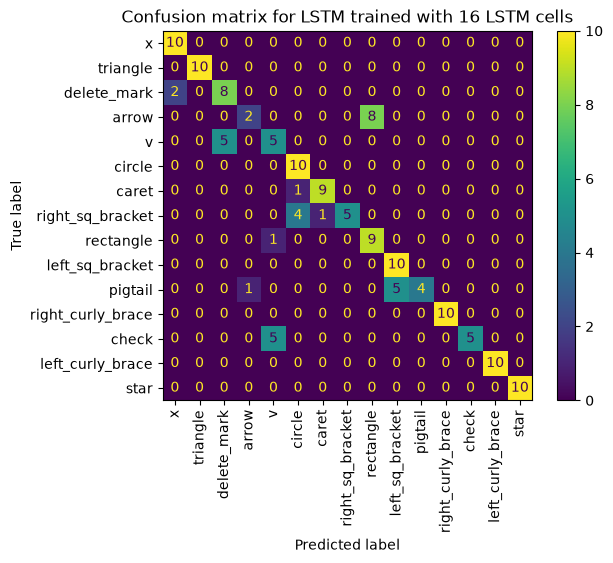

In [36]:
plt.figure(figsize=(10, 10))

# let the model make predictions for our training data
start_time = time.time()
y_predictions = model.predict(X_test)
duration = time.time() - start_time
prediction_time = duration / len(X_test)

y_predictions = np.argmax(y_predictions, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

# print('probabilities', y_predictions)

# create and plot confusion matrix
conf_matrix = confusion_matrix(y_test_labels, y_predictions)


ConfusionMatrixDisplay(conf_matrix, display_labels=set(labels)).plot()

plt.title(f"Confusion matrix for LSTM trained with {LSTM_UNITS} LSTM cells")

plt.xticks(rotation=90, ha='center')

plt.savefig(f"./plots/conf_matrix{LSTM_UNITS}.png", dpi=300)


In [43]:
from dollar_recognizer import DollarRegcognizer
from geometry import Point

dollar_rec = DollarRegcognizer(600)  # size of captured gestures
dollar_rec.add_all_gestures()

all_candidates = []


for gesture in X_test:
    gesture_points = []
    for point in gesture:
        new_point = Point(-point[0], -point[1]) # flip to convert to recognizer space
        gesture_points.append(new_point)
    all_candidates.append(gesture_points)

results = [] 
y_test_labels
labels_encoded = encoder.fit_transform(labels)

correct = 0
duration = 0
for i, candidate in enumerate(all_candidates):
    result = dollar_rec.recognize(candidate)
   
    duration += result.time
    if result.name == own_labels[i]:
        correct += 1
    
accuracy = correct / len(all_candidates)
print("accuracy: ", accuracy)
print("duration: ", duration)
prediction_time = duration / len(X_test) # avg prediction time
    
    

accuracy:  0.6133333333333333
duration:  3.0819809436798096


In [20]:
prediction_times = []
total_durations = []
#run only once for new list (values from LSTM runs, only add recognizer result)

In [44]:
total_durations.append(duration) # run with every (reduced model)
prediction_times.append(prediction_time)


In [45]:
print(prediction_times)
print(total_durations)

[0.0012861410776774088, 0.0039460515975952145, 0.0011050065358479818, 0.020546539624532064]
[0.19292116165161133, 0.5919077396392822, 0.16575098037719727, 3.0819809436798096]


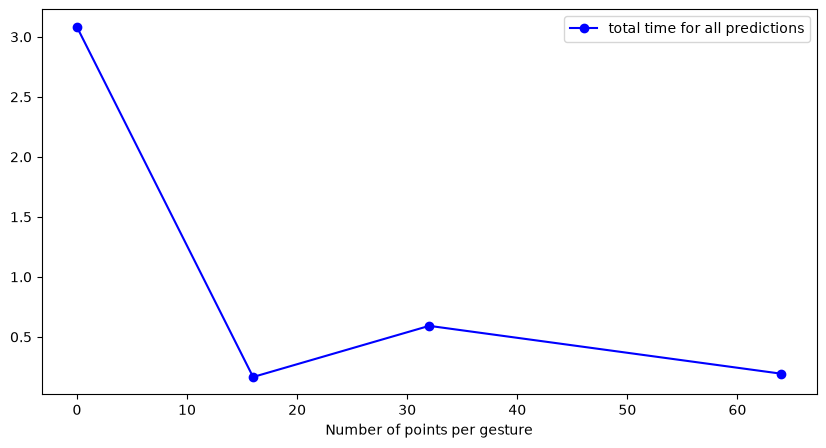

In [48]:
# plot at the end
plt.figure(figsize=(10, 5))
# plt.plot([64, 32, 16, 0], prediction_times, marker='o', color='green', label="time per prediction")
plt.plot([64, 32, 16, 0], total_durations, marker='o', color='blue', label="total time for all predictions")
plt.xlabel("Number of points per gesture")

plt.legend()
plt.savefig(f"./plots/time_comparison_total.png", dpi=300)

### Results

![Accuracy and Loss Plot for Model with 64 LSTM Units](./plots/accuracy_and_loss64.png)
![Accuracy and Loss Plot for Model with 32 LSTM Units](./plots/accuracy_and_loss32.png)
![Accuracy and Loss Plot for Model with 16 LSTM Units](./plots/accuracy_and_loss16.png)

- accuracy for dollar recognizer: 0.6133333333333333


![Confusion Matrix for Model with 64 LSTM Units](./plots/conf_matrix64.png)
![Confusion Matrix for Model with 32 LSTM Units](./plots/conf_matrix32.png)
![Confusion Matrix for Model with 16 LSTM Units](./plots/conf_matrix16.png)

![Prediction Time Comparison of Models (per Prediction)](./plots/time_comparison_per_prediction.png)
![Prediction Time Comparison of Models (for all Test Images)](./plots/time_comparison_total.png)


- total duration for dollar recognizer:  3.007869243621826


### Final Choice
- For practical application I would choose the model with 64 LSTM units. 
- This model shows the least confusion and reaches a really good accuracy. Only the model with 32 LSTM units is slighly better in terms of accuracy. This could also be different for larger test datasets.
- When it comes to prediction times the 64-model performs best (fastet) and the 32-model is actually the slowest model. In real time interactive systems the 64-model therefore has an important advantage here. 
- In other scenarios where prediction time is not that important, the 32-model might be the preferred model.
- Also, it is important that the 64-model needs more time for training and is also larger, because of more parameters. But normally this should not be a problem for most systems.
- The 1$-recognizer actually performs worst in terms of prediction time and accuracy.
